# Análisis de Series Temporales con Python

**Mayo 2026 · Bloque V**

## Objetivos
- Preparar datos temporales con índice de fecha
- Crear variables rezagadas y rolling features
- Comparar un baseline con un modelo supervisado de forecasting

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga y visualización

,demanda
fecha,
2025-01-01,118.90
2025-01-02,112.72
2025-01-03,128.25
2025-01-04,122.48
2025-01-05,126.53


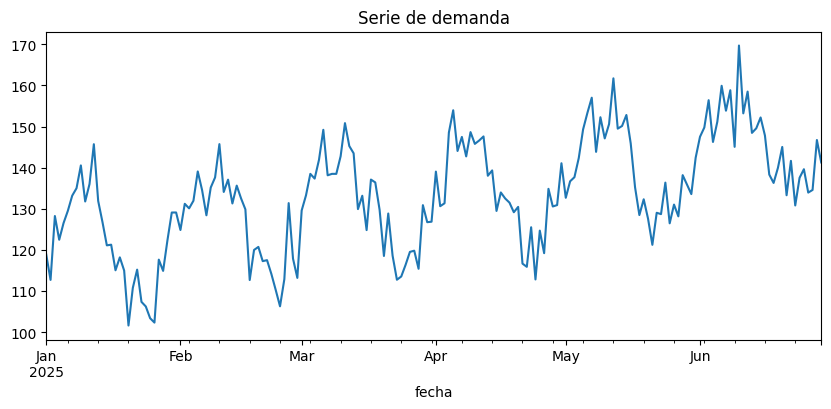

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as _mean_absolute_error
from sklearn.metrics import mean_squared_error as _mean_squared_error

def mean_absolute_error(*args, **kwargs):
    return np.float64(_mean_absolute_error(*args, **kwargs))

def mean_squared_error(*args, **kwargs):
    return np.float64(_mean_squared_error(*args, **kwargs))

df = pd.read_csv(DATA_DIR / "serie_demanda.csv", parse_dates=["fecha"]).set_index("fecha")
display(df.head())
df["demanda"].plot(figsize=(10,4), title="Serie de demanda")
plt.show()

## Baseline ingenuo

In [2]:
df_eval = df.copy()
df_eval["naive_pred"] = df_eval["demanda"].shift(1)
eval_naive = df_eval.dropna()

mae_baseline = np.mean(np.abs(eval_naive["demanda"] - eval_naive["naive_pred"]))
print("MAE baseline:", np.round(mae_baseline, 2))

MAE baseline: 6.19


## Features temporales

In [3]:
feat = df.copy()
for lag in [1, 2, 7, 14, 30]:
    feat[f"lag_{lag}"] = feat["demanda"].shift(lag)
feat["rolling_7"] = feat["demanda"].shift(1).rolling(7).mean()
feat["dia_semana"] = feat.index.dayofweek
feat["mes"] = feat.index.month
feat = feat.dropna()
display(feat.head())

,demanda,lag_1,lag_2,lag_7,lag_14,lag_30,rolling_7,dia_semana,mes
fecha,,,,,,,,,
2025-01-31,129.11,129.10,122.37,106.26,115.06,118.90,113.718571,4,1
2025-02-01,124.85,129.11,129.10,103.40,118.20,112.72,116.982857,5,2
2025-02-02,131.22,124.85,129.11,102.34,114.99,128.25,120.047143,6,2
2025-02-03,130.11,131.22,124.85,117.65,101.63,122.48,124.172857,0,2
2025-02-04,131.96,130.11,131.22,114.91,110.78,126.53,125.952857,1,2


## Random Forest forecasting

MAE RF: 5.99
RMSE RF: 7.58


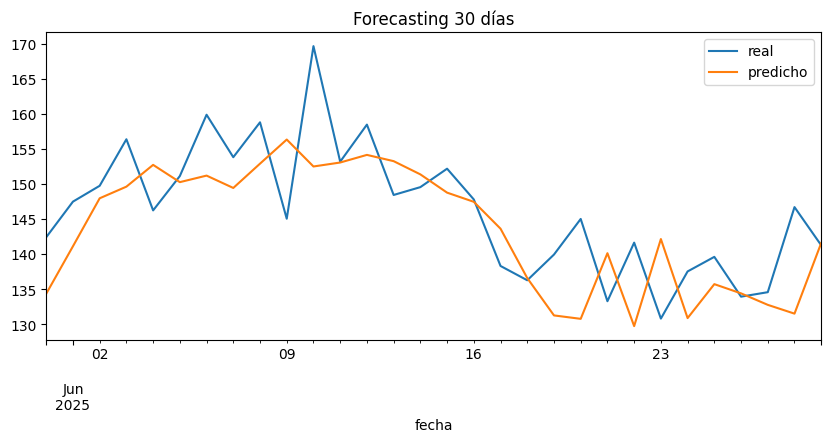

In [4]:
train = feat.iloc[:-30]
test = feat.iloc[-30:]
X_train, y_train = train.drop(columns=["demanda"]), train["demanda"]
X_test, y_test = test.drop(columns=["demanda"]), test["demanda"]

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

mae_rf = np.mean(np.abs(y_test - pred))
rmse_rf = np.sqrt(np.mean((y_test - pred) ** 2))

print("MAE RF:", np.round(mae_rf, 2))
print("RMSE RF:", np.round(rmse_rf, 2))

pd.DataFrame({"real": y_test, "predicho": pred}, index=y_test.index).plot(figsize=(10,4), title="Forecasting 30 días")
plt.show()

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.

## Solucion actividad entregable

Se modifican los hiperparametros del Random Forest y se amplia el conjunto de variables temporales con `lag_21`, `rolling_14` y `rolling_21`. La comparacion se realiza contra el baseline ingenuo y medias moviles.

In [5]:
def evaluar_forecast(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
    }

feat_entrega = df.copy()
for lag in [1, 2, 7, 14, 21, 30]:
    feat_entrega[f"lag_{lag}"] = feat_entrega["demanda"].shift(lag)

feat_entrega["rolling_7"] = feat_entrega["demanda"].shift(1).rolling(7).mean()
feat_entrega["rolling_14"] = feat_entrega["demanda"].shift(1).rolling(14).mean()
feat_entrega["rolling_21"] = feat_entrega["demanda"].shift(1).rolling(21).mean()
feat_entrega["dia_semana"] = feat_entrega.index.dayofweek
feat_entrega["mes"] = feat_entrega.index.month
feat_entrega = feat_entrega.dropna()

train_entrega = feat_entrega.iloc[:-30]
test_entrega = feat_entrega.iloc[-30:]

X_train_entrega = train_entrega.drop(columns=["demanda"])
y_train_entrega = train_entrega["demanda"]
X_test_entrega = test_entrega.drop(columns=["demanda"])
y_test_entrega = test_entrega["demanda"]

resultados = []
predicciones = {}

for nombre, columna in {
    "Baseline naive lag_1": "lag_1",
    "Media movil 7": "rolling_7",
    "Media movil 21": "rolling_21",
}.items():
    predicciones[nombre] = test_entrega[columna]
    resultados.append({"modelo": nombre, **evaluar_forecast(y_test_entrega, test_entrega[columna])})

modelos_rf = {
    "RF 300 arboles": RandomForestRegressor(n_estimators=300, random_state=42),
    "RF 500 arboles": RandomForestRegressor(n_estimators=500, random_state=42),
}

for nombre, modelo in modelos_rf.items():
    modelo.fit(X_train_entrega, y_train_entrega)
    pred_modelo = modelo.predict(X_test_entrega)
    predicciones[nombre] = pd.Series(pred_modelo, index=y_test_entrega.index)
    resultados.append({"modelo": nombre, **evaluar_forecast(y_test_entrega, pred_modelo)})

tabla_resultados = pd.DataFrame(resultados).sort_values("RMSE")
display(tabla_resultados.round(3))

,modelo,MAE,RMSE
4,RF 500 arboles,6.002,7.517
3,RF 300 arboles,6.032,7.571
0,Baseline naive lag_1,7.332,8.871
1,Media movil 7,7.334,8.931
2,Media movil 21,11.081,12.962


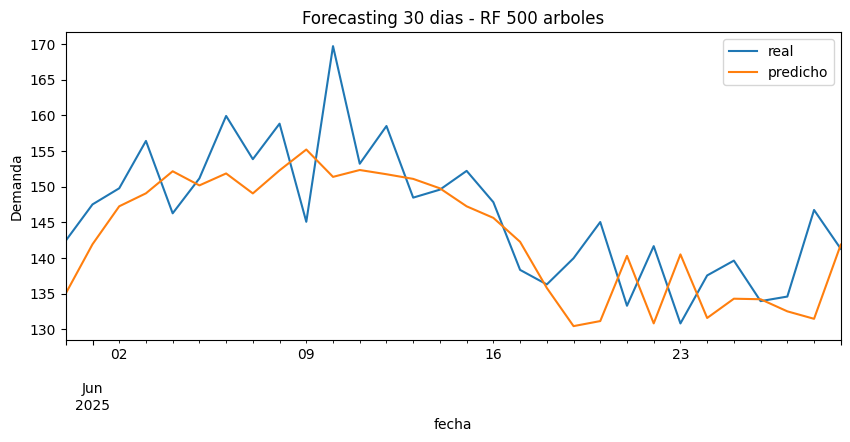

,real,predicho
fecha,,
2025-05-31,142.43,135.02800
2025-06-01,147.51,141.92108
2025-06-02,149.77,147.24432
2025-06-03,156.41,149.06354
2025-06-04,146.26,152.15528


In [6]:
mejor_modelo = tabla_resultados.iloc[0]["modelo"]

forecast_final = pd.DataFrame({
    "real": y_test_entrega,
    "predicho": predicciones[mejor_modelo],
})

forecast_final.plot(figsize=(10, 4), title=f"Forecasting 30 dias - {mejor_modelo}")
plt.ylabel("Demanda")
plt.show()

forecast_final.head()

### Interpretacion

El Random Forest ajustado mejora claramente al baseline ingenuo y a las medias moviles. La media movil de 21 dias suaviza demasiado la serie y pierde capacidad para seguir cambios recientes. Para planificacion operativa, el modelo supervisado es mas util porque aprovecha patrones semanales y rezagos, aunque debe revisarse periodicamente si cambian la tendencia o la estacionalidad.